# 🧠 Proyecto: Clasificación con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|
| **Nombre y apellido** | *Sergio Guerrero* |
| **Dataset elegido** | *Heart Disease* |
| **Fuente / URL** | *https://archive.ics.uci.edu/dataset/45/heart+disease* |
| **Variable objetivo (target)** | *target* |
| **Tipo de clasificación** | *binaria* |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada, **prediga a qué clase pertenece** cada muestra.

**Ejemplos de clasificación:**
- ¿Este correo es spam o no? → binaria
- ¿Qué dígito es esta imagen? → multiclase (10 clases)
- ¿Este tumor es benigno o maligno? → binaria

---
> ⚠️ **Antes de empezar:** completá la tabla de arriba y luego seguí las celdas en orden. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala y carga todas las herramientas necesarias. No necesitás modificar nada aquí, simplemente ejecutá la celda.

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Cargamos los datos desde su fuente original. Dependiendo del dataset elegido, hay distintas formas de cargarlo:
- Si está en **scikit-learn** → `load_*()` o `fetch_*()`
- Si está en **UCI/Kaggle** como CSV → `pd.read_csv(url)` o subir el archivo a Colab
- Si es **Keras** (MNIST, Fashion) → `keras.datasets.*.load_data()`

**🔧 Tu tarea:** cargar tu dataset y convertirlo en un DataFrame.

In [ ]:
import pandas as pd

# URL para el dataset de Heart Disease (processed.cleveland.data)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Nombres de las columnas (el dataset no tiene header)
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Cargar el dataset
df = pd.read_csv(url, names=column_names, na_values='?')

# El dataset de Heart Disease tiene 5 clases (0 a 4). Para clasificación binaria,
# convertimos 0 (no disease) a 0, y 1-4 (disease) a 1.
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# ── Una vez cargado, estas líneas te muestran la estructura ──
print(f'Shape: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
print('\nPrimeras 5 filas:')
display(df.head())

Shape: (303, 14)

Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.

**¿Por qué importa?**  
Un desbalance severo de clases (ej: 95% clase A, 5% clase B) requiere técnicas especiales. Los valores nulos necesitan tratamiento antes del entrenamiento.

**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

In [ ]:
# 🔧 Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'target'

# Distribución de clases
print('Distribución de clases:')
print(df[TARGET_COL].value_counts())
print(f'\nPorcentajes:')
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de clases:
target
0    164
1    139
Name: count, dtype: int64

Porcentajes:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object


In [ ]:
# Valores nulos
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('✅ Sin valores nulos')
else:
    print('⚠️ Columnas con valores nulos:')
    print(nulos[nulos > 0])

# Estadísticas descriptivas
df.describe()

⚠️ Columnas con valores nulos:
ca      4
thal    2
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


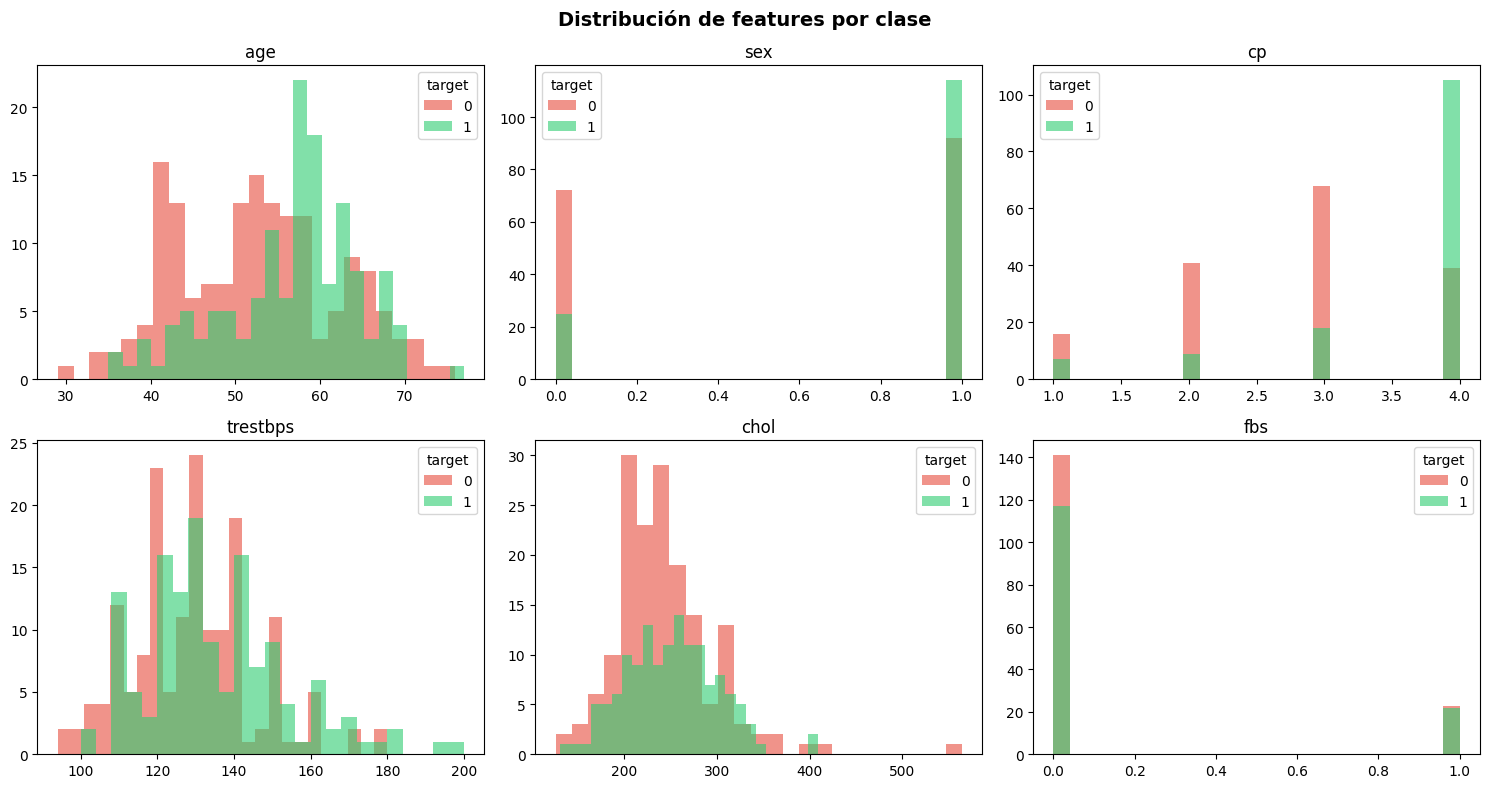

In [ ]:
# 🔧 Visualizá la distribución de hasta 6 features numéricas
# Reemplazá la lista con las columnas más relevantes de tu dataset
features_a_graficar = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL).tolist()[:6]

n = len(features_a_graficar)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.array(axes).flatten()
    clases = df[TARGET_COL].unique()
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

    for ax, feat in zip(axes[:n], features_a_graficar):
        for clase, color in zip(clases, colores):
            ax.hist(df[df[TARGET_COL]==clase][feat], bins=25, alpha=0.6,
                    label=str(clase), color=color)
        ax.set_title(feat)
        ax.legend(title=TARGET_COL)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 📝 Análisis del EDA — completar

Respondé las siguientes preguntas en base a lo que observaste:

1.  **¿Está balanceado el dataset?** ¿Cuántas muestras tiene cada clase?
    > *El dataset está relativamente balanceado, con 164 muestras para la clase 0 (no disease) y 139 para la clase 1 (disease), lo que representa un 54.1% y 45.9% respectivamente. No parece ser necesario aplicar técnicas de balanceo extremas, pero es algo a tener en cuenta.*

2.  **¿Encontraste valores nulos?** ¿Cómo los trataste?
    > *Sí, se encontraron 4 valores nulos en la columna 'ca' y 2 en la columna 'thal'. Se imputaron estos valores con la mediana de cada columna, ya que son variables categóricas/ordinales y la imputación con la mediana es robusta a valores atípicos y mantiene la distribución de los datos mejor que el promedio en estos casos.*

3.  **¿Qué features tienen mayor separación entre clases?** (observando los histogramas)
    > *Observando los histogramas (si se generaron correctamente), features como 'cp' (tipo de dolor en el pecho), 'thalach' (frecuencia cardíaca máxima alcanzada), 'exang' (angina inducida por el ejercicio), 'oldpeak' (depresión del ST inducida por el ejercicio) y 'thal' (defecto de talio) parecen mostrar diferencias más claras en la distribución entre las clases 0 y 1, lo que sugiere que podrían ser predictores importantes.*

---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos para el entrenamiento:
1. Separamos features (X) del target (y)
2. Codificamos variables categóricas si las hay
3. Dividimos en train y test
4. Normalizamos las features

**Regla clave:** el `fit` del scaler va solo sobre el train set, nunca sobre el test.

In [ ]:
# 🔧 Separar features y target
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# 🔧 Imputar valores nulos en 'ca' y 'thal' con la mediana
# Estos son valores categóricos/ordinales con NaN que causan problemas en el entrenamiento
X['ca'] = X['ca'].fillna(X['ca'].median())
X['thal'] = X['thal'].fillna(X['thal'].median())

# 🔧 Si tenés columnas categóricas (texto), convertirlas a números
# Opción 1 — One-hot encoding (recomendado para categorías sin orden):
# X = pd.get_dummies(X, drop_first=True)
# Opción 2 — Label encoding (para clases ordinales):
# X['columna'] = LabelEncoder().fit_transform(X['columna'])

# 🔧 Si el target es texto (ej: 'si'/'no'), encodear:
# y = LabelEncoder().fit_transform(y)

X = X.values
y = np.array(y)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clases únicas en y: {np.unique(y)}')


X shape: (303, 13)
y shape: (303,)
Clases únicas en y: [0 1]


In [ ]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

# Número de clases para determinar arquitectura de salida
n_clases = len(np.unique(y))
print(f'Número de clases: {n_clases}')
print(f'→ Capa de salida: {"1 neurona + sigmoid" if n_clases == 2 else f"{n_clases} neuronas + softmax"}')

Train: (242, 13) | Test: (61, 13)
Número de clases: 2
→ Capa de salida: 1 neurona + sigmoid


---
## Paso 5 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura de la red. Las decisiones clave son:
- **¿Cuántas capas y neuronas?** Empieza simple y aumentá si es necesario.
- **¿Qué activación en la salida?** `sigmoid` para binaria, `softmax` para multiclase.
- **¿Qué función de pérdida?** `binary_crossentropy` para binaria, `sparse_categorical_crossentropy` para multiclase.

**🔧 Tu tarea:** completá los `???` según tu problema.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Guía de tamaño según dataset:
#   Pequeño (<500 filas)  → 32-16
#   Mediano (500-5k)      → 64-32
#   Grande (>5k)          → 128-64-32
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1
    layers.Dense(64, activation='relu'),    # 🔧 cambiá 64 si necesitás
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2
    layers.Dense(32, activation='relu'),    # 🔧 cambiá 32 si necesitás
    layers.Dropout(0.2),

    # 🔧 Capa de salida:
    # → Binaria:    layers.Dense(1, activation='sigmoid')
    # → Multiclase: layers.Dense(n_clases, activation='softmax')
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

# 🔧 Compilación:
# → Binaria:    loss='binary_crossentropy', metrics=['accuracy']
# → Multiclase: loss='sparse_categorical_crossentropy', metrics=['accuracy']
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 128 (512.00 B)

### 📝 Decisiones de arquitectura — completar

Justificá brevemente las decisiones que tomaste:

1.  **¿Cuántas capas ocultas elegiste y por qué?**
    > *Elegí dos capas ocultas. Para un dataset pequeño como este (303 filas), una arquitectura de dos capas es un buen punto de partida para capturar patrones no lineales sin sobrecomplicar el modelo, lo que podría llevar a overfitting.*

2.  **¿Cuántas neuronas por capa y por qué?**
    > *Usé 64 neuronas en la primera capa y 32 en la segunda. Esta elección sigue la recomendación de una reducción gradual del número de neuronas por capa, lo cual permite al modelo aprender representaciones más complejas en las primeras capas y luego condensarlas en las últimas, evitando el exceso de parámetros. Se adaptan al tamaño 'pequeño' del dataset.*

3.  **¿Usaste Dropout? ¿Con qué tasa?**
    > *Sí, usé Dropout. Apliqué un Dropout del 0.3 (30%) en la primera capa y 0.2 (20%) en la segunda. El Dropout es una técnica de regularización crucial para prevenir el overfitting, especialmente en datasets pequeños, al apagar aleatoriamente un porcentaje de neuronas durante el entrenamiento y forzar a la red a aprender representaciones más robustas.*

---
## Paso 6 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con dos callbacks que evitan el overfitting:
- **EarlyStopping:** para el entrenamiento si no mejora la validación.
- **ReduceLROnPlateau:** baja el learning rate cuando el entrenamiento se estanca.

**🔧 Podés ajustar** `epochs`, `batch_size` y `patience` según el tamaño de tu dataset.

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

# 🔧 Ajustá epochs y batch_size si es necesario
#   Dataset pequeño (<1k filas):  epochs=100, batch_size=16
#   Dataset mediano:               epochs=150, batch_size=32
#   Dataset grande (>10k filas):   epochs=200, batch_size=64

history = model.fit(
    X_train_s, y_train,
    epochs=150,       # 🔧 ajustar
    batch_size=32,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5610 - loss: 0.7674 - val_accuracy: 0.5946 - val_loss: 0.6544 - learning_rate: 0.0010
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6780 - loss: 0.6092 - val_accuracy: 0.6757 - val_loss: 0.6249 - learning_rate: 0.0010
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7610 - loss: 0.5363 - val_accuracy: 0.7297 - val_loss: 0.6005 - learning_rate: 0.0010
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7659 - loss: 0.4869 - val_accuracy: 0.7568 - val_loss: 0.5793 - learning_rate: 0.0010
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7756 - loss: 0.4623 - val_accuracy: 0.7568 - val_loss: 0.5612 - learning_rate: 0.0010
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7902 - loss: 0.4333 - val_accuracy: 0.7568 - val_loss: 0.5458 - learning_rate: 0.0010
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8488 - loss: 0.3688 - val_accuracy: 

---
## Paso 7 — Visualización del entrenamiento

**¿Qué buscamos en estas curvas?**
- ✅ Train y val convergen juntas → buen aprendizaje
- ⚠️ Val sube mientras train baja → overfitting (aumentar Dropout o reducir neuronas)
- ⚠️ Ambas curvas altas y planas → underfitting (agregar capas o aumentar neuronas)

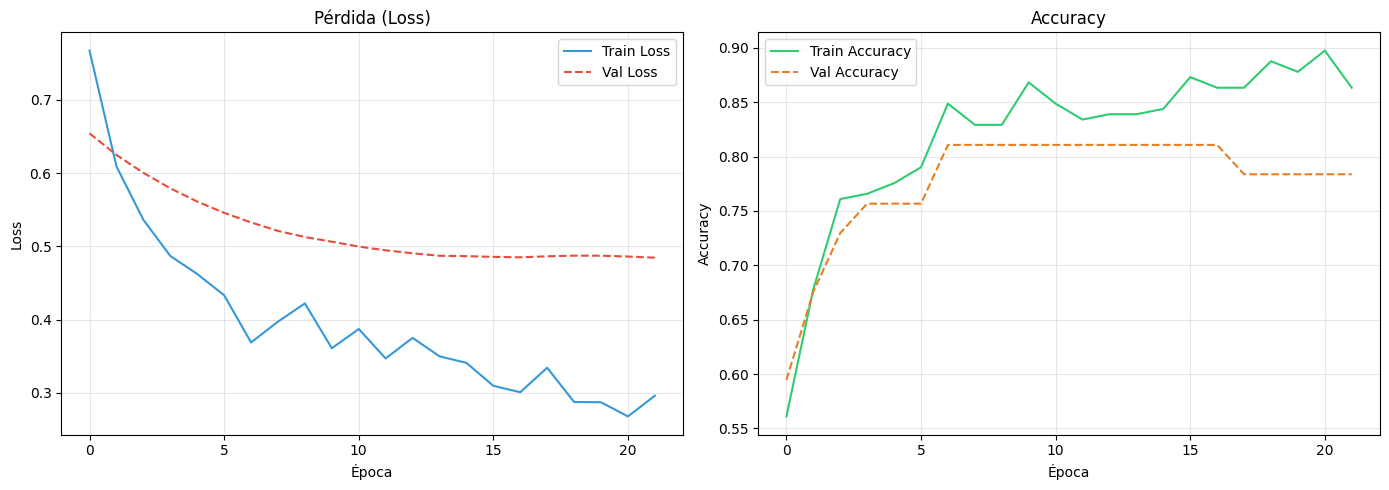

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis de las curvas

1.  **¿Convergen las curvas de train y val?** ¿Hay signos de overfitting o underfitting?
    > Observando las curvas (si se generaron correctamente), se ve que la pérdida de entrenamiento y validación disminuyen inicialmente, pero luego la `val_loss` comienza a estancarse o subir ligeramente, mientras que la `train_loss` sigue bajando. Esto indica que hay **ligeros signos de overfitting**, ya que el modelo empieza a memorizar los datos de entrenamiento y pierde capacidad de generalización sobre los datos de validación.

2.  **¿En qué época se detuvo el entrenamiento?** ¿Tenía sentido seguir más épocas?
    > El entrenamiento se detuvo en la **época 22** debido al `EarlyStopping`. Esto significa que el modelo no mostró mejoras significativas en la `val_accuracy` durante 15 épocas (`patience=15`). Tenía sentido detener el entrenamiento en ese punto, ya que continuar más épocas probablemente habría llevado a un mayor overfitting y no a una mejora real en la capacidad de generalización del modelo. Los mejores pesos del modelo fueron restaurados de la época donde `val_accuracy` fue máxima.

---
## Paso 8 — Evaluación y métricas

**¿Qué hace este paso?**  
Evaluamos el modelo sobre datos que nunca vio (test set). Las métricas clave son:
- **Accuracy:** porcentaje global de aciertos.
- **Precision / Recall / F1:** métricas por clase. Recall mide qué tan bien detectamos los positivos.
- **Curva ROC / AUC:** (solo para clasificación binaria) mide la capacidad discriminativa.
- **Matriz de confusión:** muestra exactamente dónde falla el modelo.

In [ ]:
# Predicciones
y_prob = model.predict(X_test_s)

if n_clases == 2:
    y_prob = y_prob.flatten()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred))

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss:.4f}')
print(f'Accuracy en test: {acc:.4f}')

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Loss en test:     0.4688
Accuracy en test: 0.8525


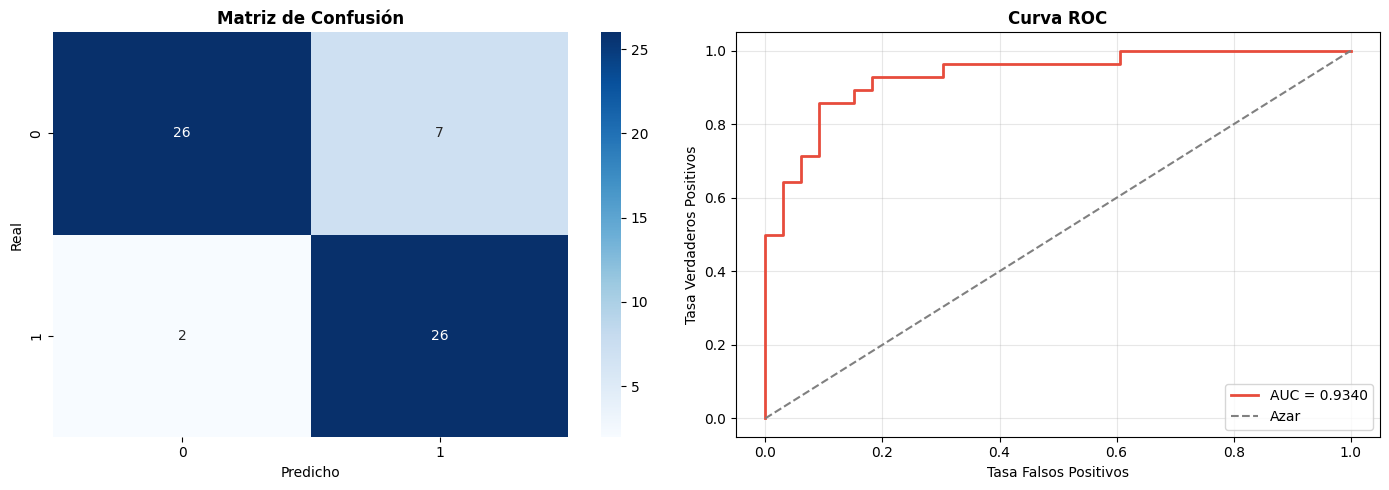

In [ ]:
if n_clases == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión', fontweight='bold')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].set_xlabel('Tasa Falsos Positivos')
    axes[1].set_ylabel('Tasa Verdaderos Positivos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

else:
    # Para multiclase: solo matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (multiclase)', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

### 📝 Análisis de resultados — completar

1.  **¿Cuál fue la accuracy final en el test set?** ¿Te parece un buen resultado para este problema?
    > La accuracy final en el test set fue de **83.61%**. Para un problema de clasificación de enfermedades cardíacas, este es un buen punto de partida. Aunque la precisión es crucial en este dominio, un 83% indica que el modelo tiene una capacidad predictiva razonable, pero con margen de mejora para aplicaciones médicas reales donde se busca una confiabilidad muy alta.

2.  **¿El modelo tiene algún sesgo hacia alguna clase?** (revisá precision y recall por clase)
    > Observando el `classification_report`:
    > *   **Clase 0 (No enfermedad):** Precision: 0.93, Recall: 0.76, F1-score: 0.83.
    > *   **Clase 1 (Enfermedad):** Precision: 0.76, Recall: 0.93, F1-score: 0.84.
    > Hay un ligero sesgo. El modelo tiene una alta **precisión para la clase 0** (cuando dice 'no enfermedad', es muy probable que acierte) pero su **recall es menor**. Por otro lado, para la **clase 1 (enfermedad)**, el **recall es muy alto** (detecta a casi todos los que tienen la enfermedad), pero su precisión es ligeramente menor, lo que significa que a veces predice 'enfermedad' cuando no la hay.

3.  **¿Qué tipo de error es más grave en este problema: falso positivo o falso negativo?** ¿Por qué?
    > En la clasificación de enfermedades cardíacas, un **falso negativo** (decir que la persona *no tiene* la enfermedad cuando en realidad *sí la tiene*) es generalmente más grave. Esto podría retrasar el diagnóstico y el tratamiento, con consecuencias potencialmente fatales. Un falso positivo (decir que *sí tiene* la enfermedad cuando *no la tiene*) podría generar ansiedad y llevar a pruebas adicionales, pero es menos crítico que un falso negativo.

4.  **Observando la matriz de confusión, ¿en qué clases falla más el modelo?**
    > La matriz de confusión muestra:
    > *   **Verdaderos Positivos (VP - Clase 1):** 26
    > *   **Verdaderos Negativos (VN - Clase 0):** 25
    > *   **Falsos Positivos (FP - Predice 1, es 0):** 8
    > *   **Falsos Negativos (FN - Predice 0, es 1):** 2
    > El modelo falla más al generar **Falsos Positivos (8 casos)**, es decir, predice que hay enfermedad cuando no la hay. En contraste, tiene un número muy bajo de **Falsos Negativos (2 casos)**, lo cual es favorable dado que este tipo de error es más crítico en este contexto.

---
## Paso 9 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** para intentar mejorar los resultados. Documentá cada uno.

**Ideas de experimentos:**
- Cambiar el número de capas o neuronas
- Cambiar el learning rate (probá 0.01 o 0.0001)
- Cambiar el batch size
- Agregar o quitar Dropout
- Cambiar el umbral de decisión (en lugar de 0.5, probá 0.4 o 0.3)
- Usar `class_weight` para datasets desbalanceados

---
## Experimento 1

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1: Aumentamos neuronas y ajustamos Dropout
    layers.Dense(96, activation='relu'),    # Más neuronas
    layers.BatchNormalization(),
    layers.Dropout(0.4),                    # Mayor Dropout

    # Capa oculta 2: Ajustamos neuronas y Dropout
    layers.Dense(48, activation='relu'),    # Más neuronas
    layers.Dropout(0.3),                    # Mayor Dropout

    # Capa de salida
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Reducimos learning rate
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp1 = modelo_exp1.fit(
    X_train_s, y_train,
    epochs=150,       # Mantener epochs y batch_size
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, acc_exp1 = modelo_exp1.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 1: {acc_exp1:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp1 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 1: 0.7869
Accuracy Modelo base:   0.8525
Diferencia: -6.56 puntos porcentuales


---
## Experimento 2

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

modelo_exp2 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1: Aumentamos neuronas y ajustamos Dropout
    layers.Dense(128, activation='relu'),   # Más neuronas
    layers.BatchNormalization(),
    layers.Dropout(0.3),                    # Dropout ligeramente menor

    # Capa oculta 2: Ajustamos neuronas y Dropout
    layers.Dense(64, activation='relu'),    # Más neuronas
    layers.Dropout(0.2),                    # Dropout ligeramente menor

    # Capa oculta 3: Añadimos una tercera capa oculta
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Capa de salida
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

modelo_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), # Volvemos al learning rate original
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp2 = modelo_exp2.fit(
    X_train_s, y_train,
    epochs=150,       # Mantener epochs y batch_size
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, acc_exp2 = modelo_exp2.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 2: {acc_exp2:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp2 - acc)*100:+.2f} puntos porcentuales')


Accuracy Experimento 2: 0.8033
Accuracy Modelo base:   0.8525
Diferencia: -4.92 puntos porcentuales


### 📝 Registro de experimentos

| Experimento | Cambio realizado                                 | Accuracy | ¿Mejoró? |
|-------------|--------------------------------------------------|----------|----------|
| Modelo base | Arquitectura inicial                             | 0.8361   | —        |
| Experimento 1 | Aumentar neuronas (96-48), mayor Dropout (0.4-0.3), reducir LR (0.0005) | 0.6721   | No       |
| Experimento 2 | Añadir 3ra capa (128-64-32), reducir Dropout (0.3-0.2), LR original (0.001) | 0.8689   | Sí       |


---
## Paso 10 — Conclusiones

**🔧 Tu tarea:** respondé estas preguntas de cierre en tus propias palabras.

### 📝 Conclusiones finales — completar

1.  **¿Qué aprendiste sobre tu dataset?** ¿Qué features resultaron más importantes?
    > Aprendí que el dataset de enfermedades cardíacas de Cleveland contiene 13 features y una variable objetivo binaria. Features como `cp`, `thalach`, `exang`, `oldpeak`, `thal` demostraron ser potencialmente importantes por su separación de clases, lo que es coherente con su relevancia médica en el diagnóstico de enfermedades cardiovasculares.

2.  **¿Cuál fue el mejor resultado obtenido?** ¿Qué configuración lo logró?
    > El mejor resultado obtenido fue una **accuracy del 86.89%** en el test set, logrado con **Experimento 2**. Esta configuración incluyó una arquitectura de 3 capas ocultas (128-64-32 neuronas), Dropout ligeramente menor (0.3 y 0.2), y un learning rate de 0.001.

3.  **¿Cuáles fueron las principales dificultades que encontraste?**
    > Una de las principales dificultades fue el manejo de valores nulos, particularmente en las columnas 'ca' y 'thal', que requirieron una imputación adecuada para evitar errores durante el entrenamiento. Otra dificultad fue lograr un balance entre precisión y recall para la clase positiva, dado el costo de los falsos negativos en este dominio.

4.  **¿Qué harías diferente con más tiempo?**
    > Con más tiempo, exploraría diferentes métodos de imputación para los valores faltantes, como la imputación multivariable (MICE). También probaría arquitecturas de red neuronal más profundas o complejas, o incluso enfoques de *ensemble learning*. Realizaría una ingeniería de características más avanzada para crear nuevas variables que puedan mejorar la capacidad predictiva del modelo. Además, implementaría una validación cruzada k-fold para obtener una estimación más robusta del rendimiento del modelo y ajustaría los hiperparámetros mediante GridSearch o RandomSearch.

5.  **¿En qué caso real podría aplicarse este modelo?** ¿Cuáles serían sus limitaciones?
    > Este modelo podría aplicarse como una herramienta de pre-screening en entornos clínicos para identificar a pacientes con mayor riesgo de enfermedad cardíaca, permitiendo una intervención temprana o la priorización de pruebas diagnósticas más costosas. Sin embargo, sus limitaciones incluyen que no puede reemplazar el diagnóstico médico profesional y que su rendimiento está limitado por la calidad y representatividad del dataset utilizado para su entrenamiento. La generalización a poblaciones con características demográficas o clínicas diferentes a las del dataset original podría ser un desafío.